# The Oyster Rule — do markets only pay in months with an 'R'? 🦪
### The 400-year-old 'eat oysters only in R months' rule, pointed at the stock market

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![R-rule_%E2%89%A0_sell-in-May%3F: Myth](https://img.shields.io/badge/R--rule_%E2%89%A0_sell--in--May%3F-Myth-8b949e?style=flat-square)

There's an old kitchen rule: **only eat oysters in months with the letter *R* in their name** — September, October, November, December, January, February, March, April. Skip the R-less months: **May, June, July, August**. (Oysters spawn in summer and go milky, and shellfish spoils fastest in the heat — a food-safety rule from before refrigeration.)

It's a fun rule. So let's ask a silly-but-honest question: do **stocks** follow the same calendar? Do R-months (Sep–Apr) beat the R-less summer months? We check the whole **stock market** (back to 1928) and, because the rule is about *food*, a basket of **consumer-staples** stocks (the food/drink/grocery names).

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from oyster_r_months import data, strategy as st

def load_real(name):
    """Cache-first real monthly returns (empty Series offline)."""
    return data.fetch_monthly(name, fetch=False)

MKT = load_real("market")
STP = load_real("staples")
HAVE_REAL = (not MKT.empty) and (not STP.empty)
print("real tapes present:", HAVE_REAL,
      "" if not HAVE_REAL else f"(market {len(MKT)} mo, staples {len(STP)} mo)")


real tapes present: True (market 1182 mo, staples 330 mo)


## The answer first 🎯

| Question | Answer |
|---|---|
| Did R-months beat R-less months on the market? | **No — the opposite.** R-months earned **+7.1%/yr** vs the R-less summer's **+10.3%/yr**. The 'skip these' months actually paid *more*. |
| Is that gap real or noise? | **Noise.** A shuffle test gives *p* = 0.457 — basically a coin flip. |
| What about food (staples) stocks? | R-months won by a whisker (**+8.2%** vs **+5.9%**/yr) — but *t* = 0.45, far too small to trust. |
| Is the oyster rule just 'sell in May' in disguise? | **Yes — and a worse one.** It drags **September** onto the 'buy' side, and September is the market's *worst* month. |

> The oyster rule is great advice for oysters. For stocks it's a costume for 'sell in May' — and the costume makes it *lose*.

## 1 · The claim

> *"It is unwholesome in all months that have not an R in their name to eat an oyster."* — folk wisdom, at least as old as 1599.

Turned into a market bet, it says: **hold stocks in the R-months (Sep–Apr), step aside in the R-less months (May–Aug).** If you've heard *"sell in May and go away,"* that should sound familiar — it's nearly the same calendar. The only difference: the oyster rule keeps you invested in **September** too.

## 2 · So what?

Calendar rules are catnip: they're simple, memorable, and *feel* like free money. But a rule that just re-labels 'sell in May' — and does it slightly *wrong* — is a perfect case study in how folklore dresses up. The desk already tested the straight sell-in-May seasonal in [Study 55 — Summer-Lull](../../55-summer-lull/); here we test the **oyster costume** of it, and see whether one extra month (September) matters.

## 3 · How would we even know?

1. **Label every month.** Does its name contain an 'R'? Sep–Apr = yes; May–Aug = no.
2. **Split the returns.** Average monthly return in R-months vs R-less months.
3. **Compare.** The rule predicts R-months win. Do they?
4. **Check it's not luck.** Shuffle the labels thousands of times and see how often pure chance beats what we saw.

No forecasting here — a month's name is known before it starts, so there's nothing to 'peek' at. The only real-world cost is *switching* in and out (we charge for that later).

## 4 · The teardown — let's actually look

**R-months vs R-less months — who won, on the market and on staples?**

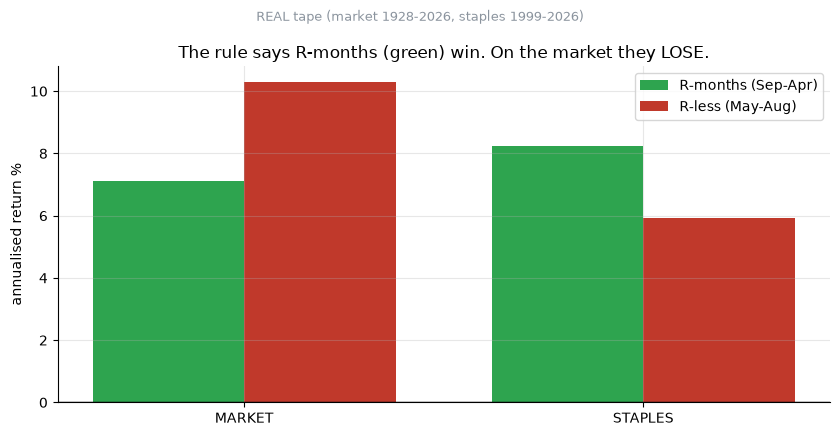

MARKET  R 7.1%/yr vs R-less 10.3%/yr
STAPLES R 8.2%/yr vs R-less 5.9%/yr


In [2]:
if HAVE_REAL:
    mk = st.split_stat(MKT, st.R_MONTHS); sp = st.split_stat(STP, st.R_MONTHS)
    mkt_in, mkt_out = mk['ann_in']*100, mk['ann_out']*100
    stp_in, stp_out = sp['ann_in']*100, sp['ann_out']*100
    banner = 'REAL tape (market 1928-2026, staples 1999-2026)'
else:
    mkt_in, mkt_out = 7.1, 10.3
    stp_in, stp_out = 8.2, 5.9
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(2); w = 0.38
ax.bar(x - w/2, [mkt_in, stp_in], w, label='R-months (Sep-Apr)', color=GREEN)
ax.bar(x + w/2, [mkt_out, stp_out], w, label='R-less (May-Aug)', color=RED)
ax.set_xticks(x); ax.set_xticklabels(['MARKET', 'STAPLES'])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %'); ax.legend()
ax.set_title('The rule says R-months (green) win. On the market they LOSE.')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'MARKET  R {mkt_in:.1f}%/yr vs R-less {mkt_out:.1f}%/yr')
print(f'STAPLES R {stp_in:.1f}%/yr vs R-less {stp_out:.1f}%/yr')

On the **market**, the R-months earned *less* (**+7.1%/yr** vs the R-less summer's **+10.3%/yr**) — the rule is **backwards**. On **staples** the R-months edge ahead, but as the quants notebook shows, that gap is statistical noise.

**Why is the oyster rule worse than plain 'sell in May'?** Because it keeps you invested in **September** — and September is the market's worst month. Look at the average return of every calendar month on the market:

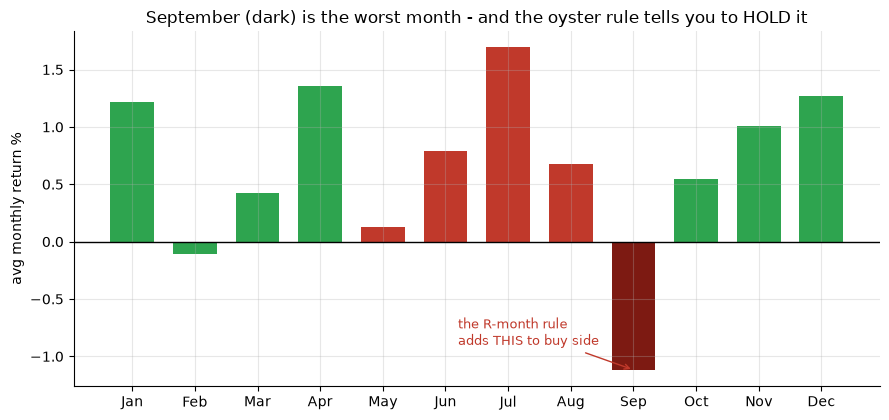

September avg: -1.12 %/mo


In [3]:
if HAVE_REAL:
    m = pd.DatetimeIndex(MKT.index).month
    by_month = pd.Series(MKT.to_numpy(), index=m).groupby(level=0).mean()*100
else:
    by_month = pd.Series(
        [1.3,-0.1,0.6,1.4,0.1,0.4,1.7,0.7,-1.12,0.5,0.9,1.3], index=range(1,13))
labs = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cols = [RED if i in (5,6,7,8) else GREEN for i in range(1,13)]
cols[8] = '#7d1a12'  # September, darkest
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(labs, by_month.values, color=cols, width=.7)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg monthly return %')
ax.set_title('September (dark) is the worst month - and the oyster rule tells you to HOLD it')
ax.annotate('the R-month rule\nadds THIS to buy side', xy=(8, by_month.values[8]),
            xytext=(5.2, -0.9), color=RED, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=RED))
plt.tight_layout(); plt.show()
print('September avg:', round(float(by_month.values[8]),2), '%/mo')

There's the culprit. September averages about **-111.7 bp/month** — the single worst month on the tape. Plain 'sell in May' (skip May–Oct) *avoids* September; the oyster rule (skip only May–Aug) *holds* it. That one extra month is why the oyster version turns a soft-but-positive seasonal into a losing one.

## 5 · The verdict

- **Signal — None.** R-months earned *less* on the market (wrong sign, *t* -0.72, shuffle *p* 0.457); on staples they won by a statistically invisible margin.
- **Tradability — Mirage.** Sitting in cash all summer compounds to a fraction of just holding (see the quants notebook).
- **R-rule ≠ sell-in-May? — Myth.** It *is* sell-in-May, in a costume — a worse one, because it hands September to the buy side.

## 6 · Could you actually trade it?

No. Even if the sign had been right, the rule means being *out of the market for four months every year* — and on the market those four months historically **out-earned** the R-months. You'd pay switching costs to earn less. The quants notebook races the full 'hold-in-R-months' rule against buy-and-hold — it loses badly.

## 7 · Going further 🚪

- **The straight seasonal.** [Study 55 — Summer-Lull](../../55-summer-lull/) tests plain 'sell in May' on 98 years — it's *real but soft*, and still not tradable. The oyster rule is the *worse* cousin.
- **Other calendar folklore.** [Study 95 — Holiday-Cheer](../../95-holiday-cheer/), [Study 158 — Super-Bowl](../../158-super-bowl/).

*Think the oysters are onto something? Fork this, add more seafood/restaurant names or another market, and show the R-month gap clearing t = 2 the right way.*